使用纯Model的方法控制标记点的运动为直线

上游代码 -> `ControlLineMPC-Qualisys.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [3]:
num:int = 1
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
j_calc_np = np.loadtxt(f'j_measure_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = ur_data['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = ur_data['actual_TCP_pose_0'].to_numpy()
rob_pose_y = ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


In [4]:
def plot_loss(loss_np):
    step_num = loss_np.shape[0]
    plot_step_num = 50

    # plot loss curve
    fig = plt.figure(figsize=(9, 3), dpi=100)
    gs = GridSpec(1, 1, figure=fig)

    # 获取 tab20 颜色映射
    colors = plt.cm.tab20.colors
    # 定义远离红色的颜色（排除红色及其相近颜色）
    filtered_colors = [color for color in colors if not (
        color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

    axs_loss = fig.add_subplot(gs[0, :])
    axs_loss.patch.set_visible(False)
    axs_loss2 = axs_loss.twinx()
    axs_loss2.set_zorder(axs_loss.get_zorder() - 1)
    axs_loss.plot(loss_np[:plot_step_num, 0], marker='.', linestyle='-', color=filtered_colors[0 % len(colors)], label=f'Distance Loss', zorder=3)
    axs_loss2.plot(loss_np[:plot_step_num, 1], marker='.', linestyle='-', color=filtered_colors[1 % len(colors)], label=f'Perpendicular Loss', zorder=1)
    # axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
    axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
    axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
    axs_loss.set_xlim([-1, plot_step_num])
    axs_loss.xaxis.set_major_locator(MultipleLocator(10))
    axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
    axs_loss.grid(True, zorder=1)

In [5]:
def plot_traj(rob_pose_x, rob_pose_y, dot_soft_np):
    fig = plt.figure(figsize=(8, 4), dpi=100)
    gs = GridSpec(1, 2, figure=fig)

    indices = np.linspace(0, len(rob_pose_x)-1, step_num, dtype=int)
    rows = np.arange(step_num)
    norm = plt.Normalize(rows.min(), rows.max())
    colors = plt.cm.plasma(norm(rows))

    axs_rob_mov = fig.add_subplot(gs[0, 0])
    rob_pose_xy = np.stack([rob_pose_x[indices][:50], rob_pose_y[indices][:50]], axis=1).reshape(-1, 1, 2)
    segments = np.concatenate([rob_pose_xy[:-1], rob_pose_xy[1:]], axis=1)
    lc = LineCollection(segments * 1000, colors=colors, norm=norm)
    axs_rob_mov.add_collection(lc)
    axs_rob_mov.autoscale()
    axs_rob_mov.set_title('Robot Tool Movement', fontsize=14, fontname='Times New Roman')
    # axs_rob_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
    # axs_rob_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_rob_mov.set_aspect('equal', 'datalim')
    axs_rob_mov.grid(True)

    axs_dot_mov = fig.add_subplot(gs[0, 1])
    init_pos = np.array([dot_soft_np[0, 1]*1000, dot_soft_np[0, 0]*1000])
    desired_pos = np.array([init_pos[0] - 0.008*1000, init_pos[1] + 0.006*1000])
    # desired_pos = np.array([init_pos[0], init_pos[1] + 0.01*1000])
    dots_soft = np.stack([dot_soft_np[:50, 1], dot_soft_np[:50, 0]], axis=1).reshape(-1, 1, 2)
    segments = np.concatenate([dots_soft[:-1], dots_soft[1:]], axis=1)
    lc = LineCollection(segments * 1000., colors=colors, norm=norm)
    axs_dot_mov.add_collection(lc)
    axs_dot_mov.autoscale()
    axs_dot_mov.scatter(init_pos[0], init_pos[1], c='blue', s=10, zorder=3)
    axs_dot_mov.scatter(desired_pos[0], desired_pos[1], c='red', s=10, zorder=3)
    axs_dot_mov.plot([init_pos[0], desired_pos[0]], [init_pos[1], desired_pos[1]], color='seagreen', linestyle='--', zorder=1)
    axs_dot_mov.set_title(f'Marker Movement', fontsize=14, fontname='Times New Roman')
    axs_dot_mov.set_aspect('equal', 'datalim')
    axs_dot_mov.grid(True, zorder=0)

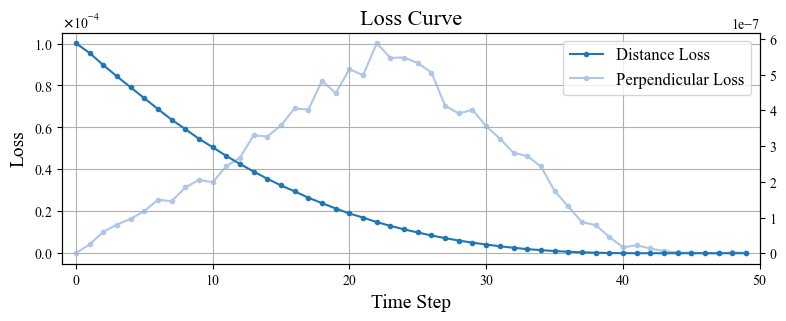

In [6]:
plot_loss(loss_np)

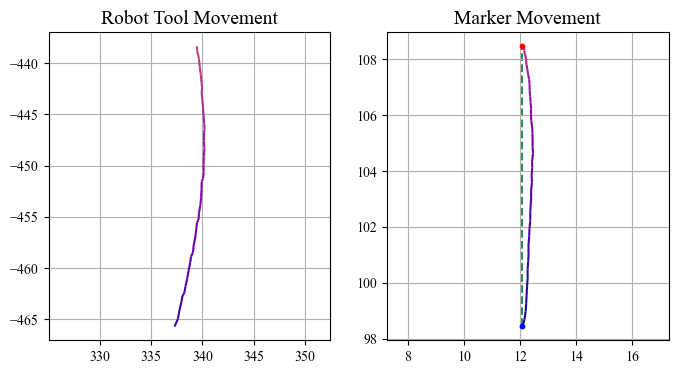

In [ ]:
plot_traj(rob_pose_x, rob_pose_y, dot_soft_np)

In [ ]:
num:int = 2
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
j_calc_np = np.loadtxt(f'j_measure_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = ur_data['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = ur_data['actual_TCP_pose_0'].to_numpy()
rob_pose_y = ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


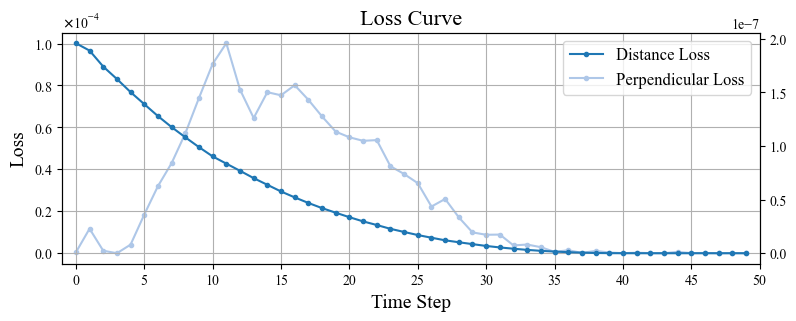

In [ ]:
plot_loss(loss_np)

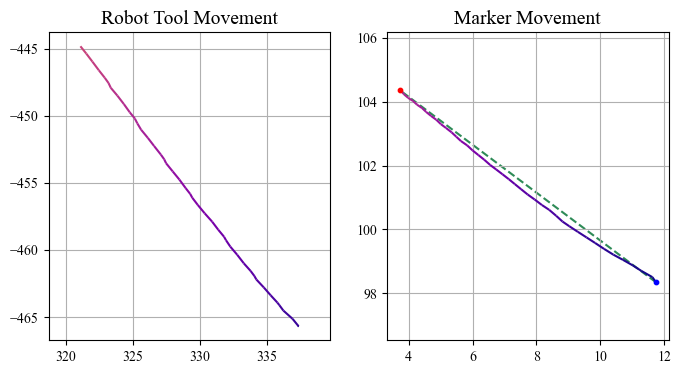

In [ ]:
plot_traj(rob_pose_x, rob_pose_y, dot_soft_np)

---
用于论文绘图

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


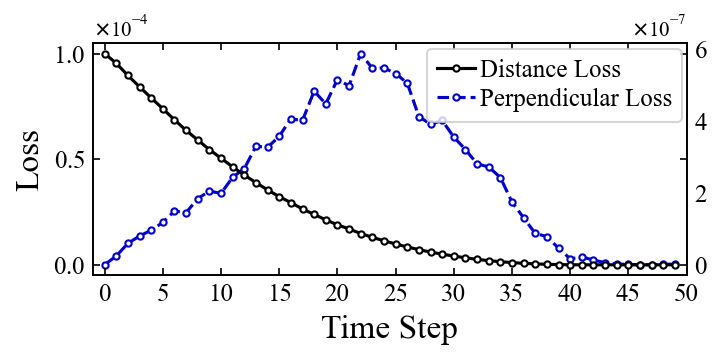

In [65]:
num:int = 1
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
j_calc_np = np.loadtxt(f'j_measure_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = ur_data['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = ur_data['actual_TCP_pose_0'].to_numpy()
rob_pose_y = ur_data['actual_TCP_pose_1'].to_numpy()

step_num = loss_np.shape[0]
plot_step_num = 50

# plot loss curve
fig = plt.figure(figsize=(5, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.patch.set_visible(False)
axs_loss2 = axs_loss.twinx()
axs_loss2.set_zorder(axs_loss.get_zorder() - 1)
axs_loss.plot(loss_np[:plot_step_num, 0], marker='.', markerfacecolor='white', linestyle='-', color='black', lw=1.5, label=f'Distance Loss', zorder=2)
axs_loss2.plot(loss_np[:plot_step_num, 1], marker='.', markerfacecolor='white', linestyle='--', color='mediumblue', lw=1.5, label=f'Perpendicular Loss', zorder=5)
# axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
# axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(5))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss2.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
fig.legend(handlelength=1.5, handletextpad=0.2, labelspacing=0.2, loc='upper right', fontsize=12, bbox_to_anchor=(1.013, 1.03), bbox_transform=axs_loss.transAxes)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_loss2.tick_params(axis='both', labelsize=12, direction='in', length=0)
# axs_loss.grid(True, zorder=0)

fig.tight_layout()
fig.savefig('liver-mpc-loss-1.svg', transparent=True, dpi=300, bbox_inches='tight')

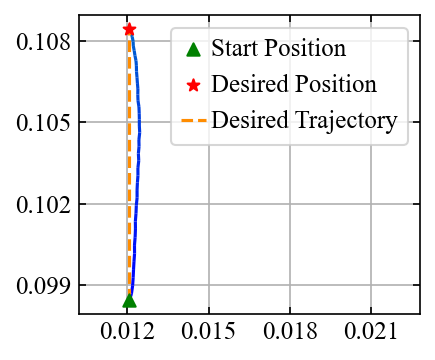

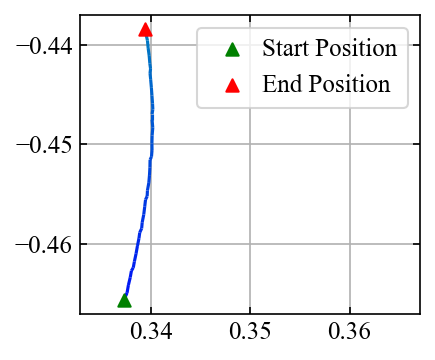

In [37]:
fig_marker = plt.figure(figsize=(3, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_marker)

indices = np.linspace(0, len(rob_pose_x)-1, step_num, dtype=int)
rows = np.arange(step_num)
norm = plt.Normalize(rows.min(), rows.max())
colors = plt.cm.winter(norm(rows))

axs_dot_mov = fig_marker.add_subplot(gs[0, 0])
init_pos = np.array([dot_soft_np[0, 1], dot_soft_np[0, 0]])
# desired_pos = np.array([init_pos[0] - 0.008*1000, init_pos[1] + 0.006*1000])
desired_pos = np.array([init_pos[0], init_pos[1] + 0.01])
# desired_pos = np.array([init_pos[0], init_pos[1] + 0.01*1000])
dots_soft = np.stack([dot_soft_np[:50, 1], dot_soft_np[:50, 0]], axis=1).reshape(-1, 1, 2)
segments = np.concatenate([dots_soft[:-1], dots_soft[1:]], axis=1)
lc = LineCollection(segments, colors=colors, norm=norm)
axs_dot_mov.add_collection(lc)
axs_dot_mov.autoscale()
axs_dot_mov.scatter(init_pos[0], init_pos[1], marker='^', c='green', s=35, label='Start Position', zorder=3)
axs_dot_mov.scatter(desired_pos[0], desired_pos[1], marker='*', c='red', s=35, label='Desired Position', zorder=3)
axs_dot_mov.plot([init_pos[0], desired_pos[0]], [init_pos[1], desired_pos[1]], color='darkorange', linestyle='--', label='Desired Trajectory', zorder=2)
# axs_dot_mov.set_title(f'Marker Movement', fontsize=14, fontname='Times New Roman')
axs_dot_mov.xaxis.set_major_locator(MultipleLocator(0.003))
axs_dot_mov.yaxis.set_major_locator(MultipleLocator(0.003))
axs_dot_mov.set_xlim([0.011, 0.022])
axs_dot_mov.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_dot_mov.set_aspect('equal', 'datalim')
axs_dot_mov.grid(True, zorder=0)
axs_dot_mov.legend(handlelength=1, handletextpad=0.2, loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_dot_mov.transAxes)

fig_marker.tight_layout()
fig_marker.savefig('liver-mpc-marker-traj-1.svg', transparent=True, dpi=300, bbox_inches='tight')
# plt.show()

fig_rob = plt.figure(figsize=(3, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_rob)
axs_rob_mov = fig_rob.add_subplot(gs[0, 0])
rob_pose_xy = np.stack([rob_pose_x[indices][:50], rob_pose_y[indices][:50]], axis=1).reshape(-1, 1, 2)
segments = np.concatenate([rob_pose_xy[:-1], rob_pose_xy[1:]], axis=1)
lc = LineCollection(segments, colors=colors, norm=norm)
axs_rob_mov.add_collection(lc)
axs_rob_mov.autoscale()
# axs_rob_mov.set_title('Robot Tool Movement', fontsize=14, fontname='Times New Roman')
axs_rob_mov.scatter(rob_pose_x[0], rob_pose_y[0], marker='^', c='green', s=35, label='Start Position', zorder=3)
axs_rob_mov.scatter(rob_pose_x[indices][50-1], rob_pose_y[indices][50-1], marker='^', c='red', s=35, label='End Position', zorder=3)

# axs_rob_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
# axs_rob_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
axs_rob_mov.xaxis.set_major_locator(MultipleLocator(0.01))
axs_rob_mov.yaxis.set_major_locator(MultipleLocator(0.01))
axs_rob_mov.set_xlim([0.33, 0.37])
axs_rob_mov.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_rob_mov.set_aspect('equal', 'datalim')
axs_rob_mov.grid(True)
axs_rob_mov.legend(handletextpad=0.2, loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_rob_mov.transAxes)

fig_rob.tight_layout()
fig_rob.savefig('liver-mpc-robot-traj-1.svg', transparent=True, dpi=300, bbox_inches='tight')

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


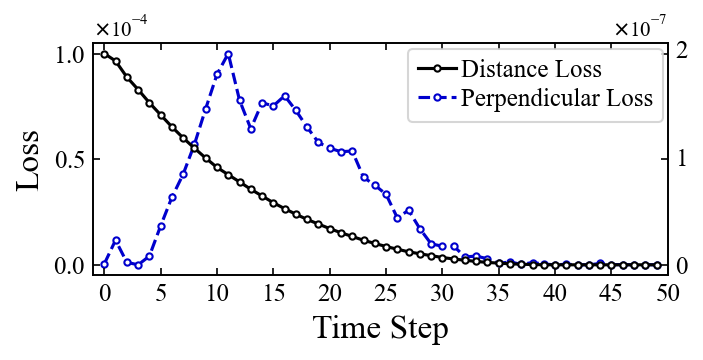

In [70]:
num:int = 2
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
j_calc_np = np.loadtxt(f'j_measure_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = ur_data['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = ur_data['actual_TCP_pose_0'].to_numpy()
rob_pose_y = ur_data['actual_TCP_pose_1'].to_numpy()

step_num = loss_np.shape[0]
plot_step_num = 50

# plot loss curve
fig = plt.figure(figsize=(5, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.patch.set_visible(False)
axs_loss2 = axs_loss.twinx()
axs_loss2.set_zorder(axs_loss.get_zorder() - 1)
axs_loss.plot(loss_np[:plot_step_num, 0], marker='.', markerfacecolor='white', linestyle='-', color='black', lw=1.5, label=f'Distance Loss', zorder=2)
axs_loss2.plot(loss_np[:plot_step_num, 1], marker='.', markerfacecolor='white', linestyle='--', color='mediumblue', lw=1.5, label=f'Perpendicular Loss', zorder=5)
# axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
# axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(5))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss2.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
fig.legend(handlelength=1.5, handletextpad=0.2, labelspacing=0.2, loc='upper right', fontsize=12, bbox_to_anchor=(1.013, 1.03), bbox_transform=axs_loss.transAxes)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_loss2.tick_params(axis='both', labelsize=12, direction='in', length=0)
# axs_loss2.grid(True, zorder=0)

fig.tight_layout()
fig.savefig('liver-mpc-loss-2.svg', transparent=True, dpi=300, bbox_inches='tight')

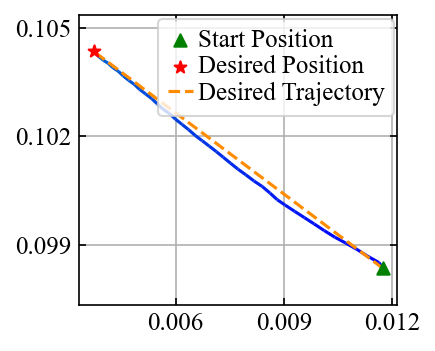

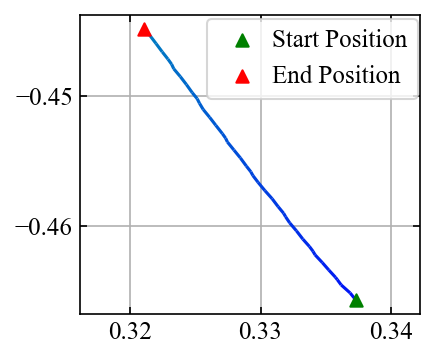

In [50]:
fig_marker = plt.figure(figsize=(3, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_marker)

indices = np.linspace(0, len(rob_pose_x)-1, step_num, dtype=int)
rows = np.arange(step_num)
norm = plt.Normalize(rows.min(), rows.max())
colors = plt.cm.winter(norm(rows))

axs_dot_mov = fig_marker.add_subplot(gs[0, 0])
init_pos = np.array([dot_soft_np[0, 1], dot_soft_np[0, 0]])
desired_pos = np.array([init_pos[0] - 0.008, init_pos[1] + 0.006])
# desired_pos = np.array([init_pos[0], init_pos[1] + 0.01])
# desired_pos = np.array([init_pos[0], init_pos[1] + 0.01*1000])
dots_soft = np.stack([dot_soft_np[:50, 1], dot_soft_np[:50, 0]], axis=1).reshape(-1, 1, 2)
segments = np.concatenate([dots_soft[:-1], dots_soft[1:]], axis=1)
lc = LineCollection(segments, colors=colors, norm=norm)
axs_dot_mov.add_collection(lc)
axs_dot_mov.autoscale()
axs_dot_mov.scatter(init_pos[0], init_pos[1], marker='^', c='green', s=35, label='Start Position', zorder=3)
axs_dot_mov.scatter(desired_pos[0], desired_pos[1], marker='*', c='red', s=35, label='Desired Position', zorder=3)
axs_dot_mov.plot([init_pos[0], desired_pos[0]], [init_pos[1], desired_pos[1]], color='darkorange', linestyle='--', label='Desired Trajectory', zorder=2)
# axs_dot_mov.set_title(f'Marker Movement', fontsize=14, fontname='Times New Roman')
axs_dot_mov.xaxis.set_major_locator(MultipleLocator(0.003))
axs_dot_mov.yaxis.set_major_locator(MultipleLocator(0.003))
axs_dot_mov.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_dot_mov.set_aspect('equal', 'datalim')
axs_dot_mov.grid(True, zorder=0)
axs_dot_mov.legend(handlelength=1, handletextpad=0.2, labelspacing=0.1, loc='upper right', fontsize=12, bbox_to_anchor=(1.03, 1.03), bbox_transform=axs_dot_mov.transAxes)

fig_marker.tight_layout()
fig_marker.savefig('liver-mpc-marker-traj-2.svg', transparent=True, dpi=300, bbox_inches='tight')
# plt.show()

fig_rob = plt.figure(figsize=(3, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_rob)
axs_rob_mov = fig_rob.add_subplot(gs[0, 0])
rob_pose_xy = np.stack([rob_pose_x[indices][:50], rob_pose_y[indices][:50]], axis=1).reshape(-1, 1, 2)
segments = np.concatenate([rob_pose_xy[:-1], rob_pose_xy[1:]], axis=1)
lc = LineCollection(segments, colors=colors, norm=norm)
axs_rob_mov.add_collection(lc)
axs_rob_mov.autoscale()
# axs_rob_mov.set_title('Robot Tool Movement', fontsize=14, fontname='Times New Roman')
axs_rob_mov.scatter(rob_pose_x[0], rob_pose_y[0], marker='^', c='green', s=35, label='Start Position', zorder=3)
axs_rob_mov.scatter(rob_pose_x[indices][50-1], rob_pose_y[indices][50-1], marker='^', c='red', s=35, label='End Position', zorder=3)

# axs_rob_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
# axs_rob_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
axs_rob_mov.xaxis.set_major_locator(MultipleLocator(0.01))
axs_rob_mov.yaxis.set_major_locator(MultipleLocator(0.01))
axs_rob_mov.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_rob_mov.set_aspect('equal', 'datalim')
axs_rob_mov.grid(True)
axs_rob_mov.legend(handletextpad=0.2, loc='upper right', fontsize=12, bbox_to_anchor=(1.03, 1.03), bbox_transform=axs_rob_mov.transAxes)

fig_rob.tight_layout()
fig_rob.savefig('liver-mpc-robot-traj-2.svg', transparent=True, dpi=300, bbox_inches='tight')